In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Bidirectional,
    LSTM,
    Dense,
    GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)
print("Seed set to:", SEED)

Libraries imported successfully.
TensorFlow version: 2.19.0
Seed set to: 42


In [3]:
# from datasets import load_dataset

# dataset = load_dataset("dnagpt/dna_splice_site_prediction")
# df = dataset["train"].to_pandas()
df = pd.read_csv("dna.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset loaded successfully.
Shape: (3186, 181)
Columns: ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'A64', 'A65', 'A66', 'A67', 'A68', 'A69', 'A70', 'A71', 'A72', 'A73', 'A74', 'A75', 'A76', 'A77', 'A78', 'A79', 'A80', 'A81', 'A82', 'A83', 'A84', 'A85', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A94', 'A95', 'A96', 'A97', 'A98', 'A99', 'A100', 'A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110', 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'A118', 'A119', 'A120', 'A121', 'A122', 'A123', 'A124', 'A125', 'A126', 'A127', 'A128', 'A129', 'A130', 'A13

,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A171,A172,A173,A174,A175,A176,A177,A178,A179,class
0,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,1,0,0,3
1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,3
2,0,0,1,0,0,1,0,1,0,0,...,0,1,0,0,0,1,0,0,1,3
3,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,1
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,1,0,0,2


In [4]:
print("Columns:", df.columns.tolist())

SEQ_COL = df.columns[0]
LABEL_COL = df.columns[1]

print("Using sequence column:", SEQ_COL)
print("Using label column:", LABEL_COL)

Columns: ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'A64', 'A65', 'A66', 'A67', 'A68', 'A69', 'A70', 'A71', 'A72', 'A73', 'A74', 'A75', 'A76', 'A77', 'A78', 'A79', 'A80', 'A81', 'A82', 'A83', 'A84', 'A85', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A94', 'A95', 'A96', 'A97', 'A98', 'A99', 'A100', 'A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110', 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'A118', 'A119', 'A120', 'A121', 'A122', 'A123', 'A124', 'A125', 'A126', 'A127', 'A128', 'A129', 'A130', 'A131', 'A132', 'A133', 'A134', 'A135', 'A136', 'A13

Class distribution:
A1
0    2352
1     834
Name: count, dtype: int64

Sequence length statistics:
count    3186.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: A0, dtype: float64


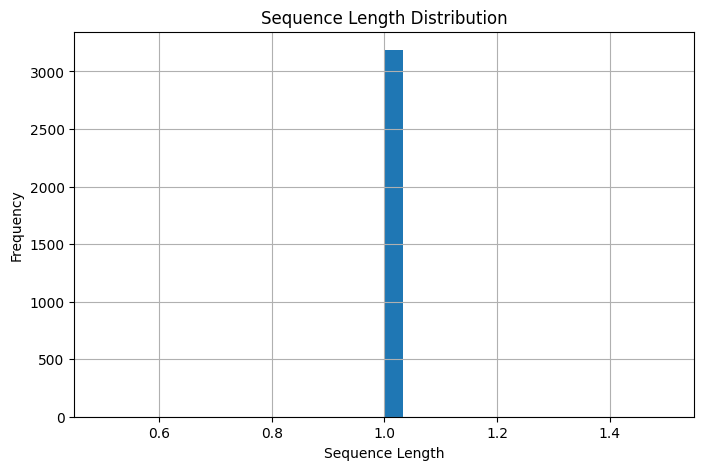

In [5]:
print("Class distribution:")
print(df[LABEL_COL].value_counts().sort_index())
print()

sequence_lengths = df[SEQ_COL].astype(str).apply(len)
print("Sequence length statistics:")
print(sequence_lengths.describe())

plt.figure(figsize=(8, 5))
plt.hist(sequence_lengths, bins=30)
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [6]:
X_seq = df[SEQ_COL].astype(str).str.upper().values
y = df[LABEL_COL].values

print("Number of sequences:", len(X_seq))
print("Number of labels:", len(y))
print("Original classes:", sorted(pd.Series(y).unique()))

Number of sequences: 3186
Number of labels: 3186
Original classes: [np.int64(0), np.int64(1)]


In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:", sorted(np.unique(y_encoded)))

y_categorical = to_categorical(y_encoded)

print("Categorical label shape:", y_categorical.shape)

Encoded classes: [np.int64(0), np.int64(1)]
Categorical label shape: (3186, 2)


In [8]:
# Old encoded dataset pipeline

X = df.drop("class", axis=1).values
y = df["class"].values

print("Feature shape before reshape:", X.shape)
print("Label shape:", y.shape)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Categorical label shape:", y_categorical.shape)

# reshape 180 features -> 60 x 3
X = X.reshape(X.shape[0], 60, 3)

print("Feature shape after reshape:", X.shape)

Feature shape before reshape: (3186, 180)
Label shape: (3186,)
Categorical label shape: (3186, 3)
Feature shape after reshape: (3186, 60, 3)


In [9]:
X_train, X_temp, y_train, y_temp, y_train_raw, y_temp_raw = train_test_split(
    X,
    y_categorical,
    y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test, y_val_raw, y_test_raw = train_test_split(
    X_temp,
    y_temp,
    y_temp_raw,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_raw
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (2548, 60, 3) (2548, 3)
Validation set: (319, 60, 3) (319, 3)
Test set: (319, 60, 3) (319, 3)


In [10]:
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_raw),
    y=y_train_raw
)

class_weights = dict(enumerate(class_weights_values))

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(1.3855356171832518), 1: np.float64(1.3877995642701526), 2: np.float64(0.6419753086419753)}


In [11]:
input_layer = Input(shape=(60, 3))

x = Conv1D(filters=64, kernel_size=5, activation="relu", padding="same")(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = GlobalMaxPooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

output_layer = Dense(3, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,763 (522.51 KB)

 Trainable params: 133,379 (521.01 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

save_best = ModelCheckpoint(
    "best_splice_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, save_best],
    verbose=1
)

Epoch 1/50
72/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4306 - loss: 1.0544
Epoch 1: val_loss improved from None to 1.07289, saving model to best_splice_model.keras

Epoch 1: finished saving model to best_splice_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4615 - loss: 0.9962 - val_accuracy: 0.2508 - val_loss: 1.0729 - learning_rate: 0.0010
Epoch 2/50
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5392 - loss: 0.8632
Epoch 2: val_loss improved from 1.07289 to 1.06887, saving model to best_splice_model.keras

Epoch 2: finished saving model to best_splice_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5565 - loss: 0.8467 - val_accuracy: 0.2602 - val_loss: 1.0689 - learning_rate: 0.0010
Epoch 3/50
77/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6194 - loss: 0.7124
Epoch 3: val_loss improved from 1.06887 to 0.98758, saving model to best_splice_model.keras

Epoch 3: finished saving model to best_splice_model.keras
80/80 ━━━━━━━━━━━━━

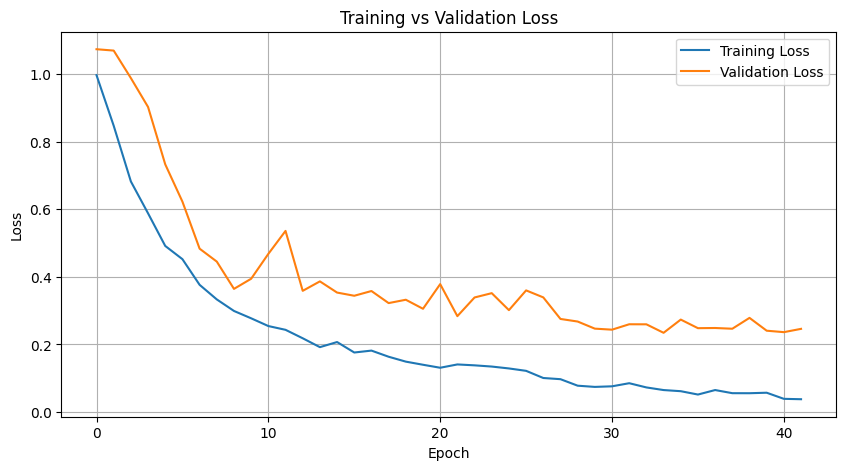

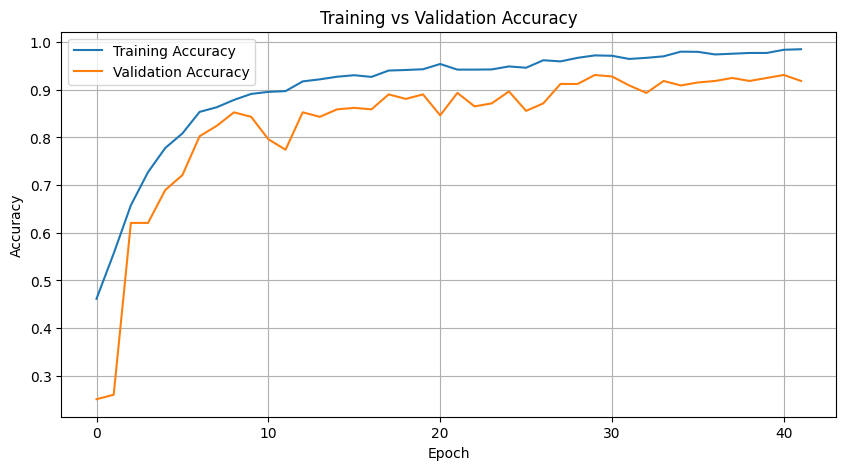

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Accuracy: 0.9404388714733543
Precision: 0.9348012130006884
Recall: 0.9431457431457432
F1 Score: 0.9385975995264925

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        77
           1       0.92      0.91      0.92        77
           2       0.96      0.93      0.94       165

    accuracy                           0.94       319
   macro avg       0.93      0.94      0.94       319
weighted avg       0.94      0.94      0.94       319



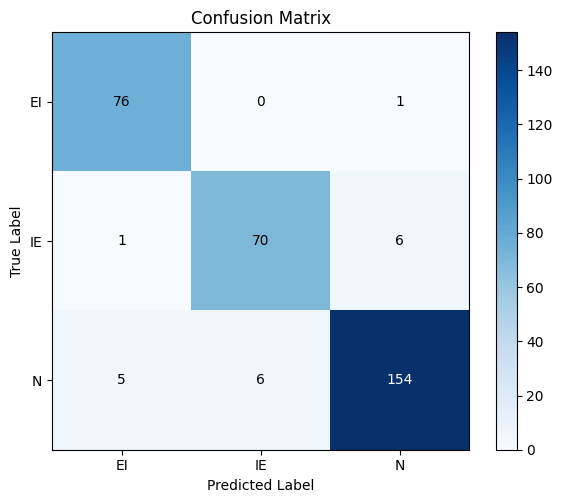

In [16]:
cm = confusion_matrix(y_true, y_pred)
class_names = ["EI", "IE", "N"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()

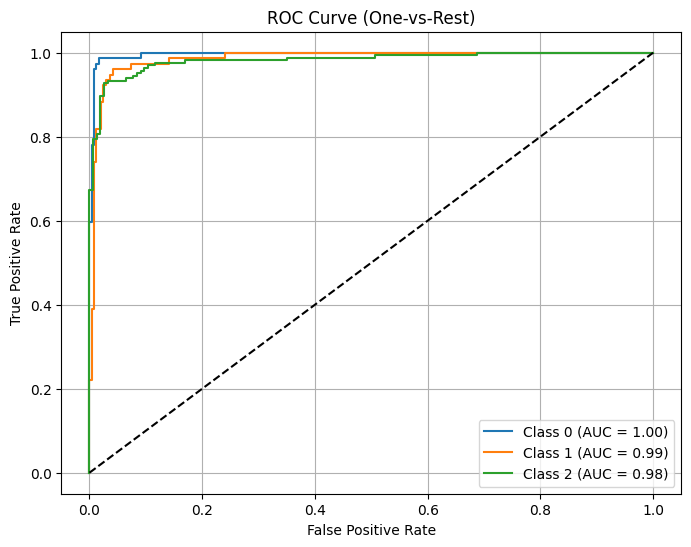

AUC scores per class: {0: np.float64(0.9961897606525705), 1: np.float64(0.9858323494687131), 2: np.float64(0.9820543093270366)}


In [17]:
n_classes = y_test.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

print("AUC scores per class:", roc_auc)

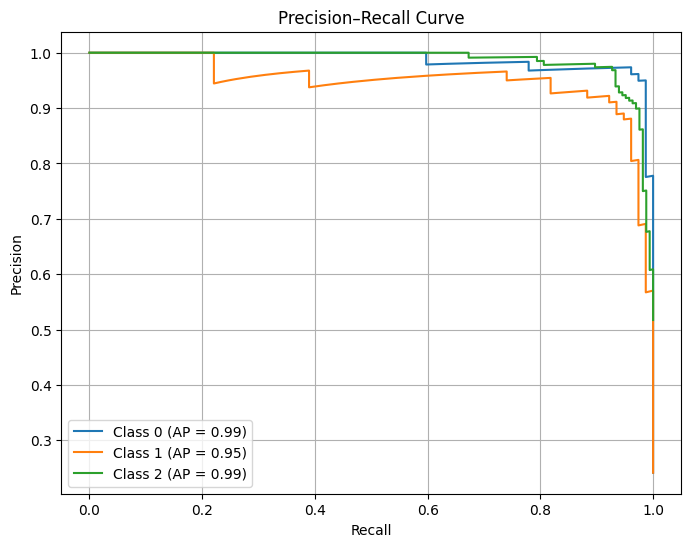

Average Precision per class: {0: np.float64(0.9873607136436112), 1: np.float64(0.9498511323533817), 2: np.float64(0.985849581948088)}


In [18]:
precision_curve = {}
recall_curve = {}
avg_precision = {}

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    precision_curve[i], recall_curve[i], _ = precision_recall_curve(y_test[:, i], y_pred_prob[:, i])
    avg_precision[i] = average_precision_score(y_test[:, i], y_pred_prob[:, i])

    plt.plot(
        recall_curve[i],
        precision_curve[i],
        label=f"Class {i} (AP = {avg_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Average Precision per class:", avg_precision)

In [19]:
report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
0,0.926829,0.987013,0.955975,77.000000
1,0.921053,0.909091,0.915033,77.000000
2,0.956522,0.933333,0.944785,165.000000
accuracy,0.940439,0.940439,0.940439,0.940439
macro avg,0.934801,0.943146,0.938598,319.000000
weighted avg,0.940793,0.940439,0.940305,319.000000


In [20]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

results = []

svm_model = SVC(kernel="rbf")
svm_model.fit(X_train_flat, y_train_labels)
svm_pred = svm_model.predict(X_test_flat)

results.append([
    "SVM",
    accuracy_score(y_test_labels, svm_pred),
    precision_score(y_test_labels, svm_pred, average="macro"),
    recall_score(y_test_labels, svm_pred, average="macro"),
    f1_score(y_test_labels, svm_pred, average="macro")
])

print("SVM Classification Report:\n")
print(classification_report(y_test_labels, svm_pred))

rf_model = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_model.fit(X_train_flat, y_train_labels)
rf_pred = rf_model.predict(X_test_flat)

results.append([
    "Random Forest",
    accuracy_score(y_test_labels, rf_pred),
    precision_score(y_test_labels, rf_pred, average="macro"),
    recall_score(y_test_labels, rf_pred, average="macro"),
    f1_score(y_test_labels, rf_pred, average="macro")
])

print("Random Forest Classification Report:\n")
print(classification_report(y_test_labels, rf_pred))

results.append([
    "CNN + BiLSTM",
    accuracy,
    precision,
    recall,
    f1
])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

display(results_df)

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.97      0.93        77
           1       0.95      0.94      0.94        77
           2       1.00      0.96      0.98       165

    accuracy                           0.96       319
   macro avg       0.95      0.96      0.95       319
weighted avg       0.96      0.96      0.96       319

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        77
           1       0.94      0.96      0.95        77
           2       0.98      0.98      0.98       165

    accuracy                           0.96       319
   macro avg       0.96      0.96      0.96       319
weighted avg       0.96      0.96      0.96       319



,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.959248,0.946742,0.957576,0.951445
1,Random Forest,0.962382,0.955262,0.957287,0.956206
2,CNN + BiLSTM,0.940439,0.934801,0.943146,0.938598


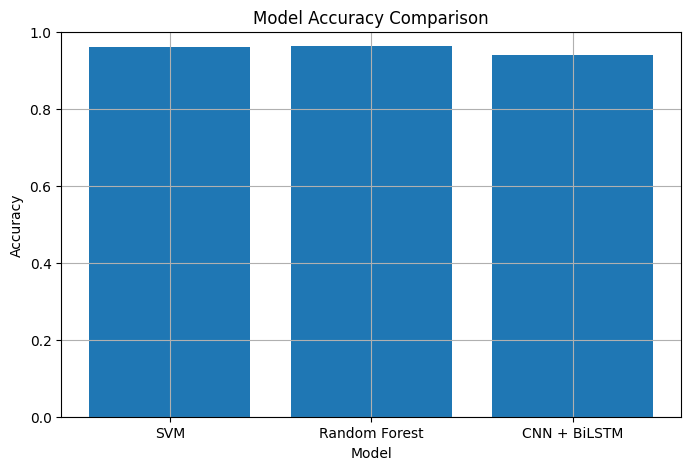

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [22]:
class_names = ["EI", "IE", "N"]

misclassified_idx = np.where(y_true != y_pred)[0]

print("Total misclassified samples:", len(misclassified_idx))

misclassified_df = pd.DataFrame({
    "Index": misclassified_idx,
    "True_Label": [class_names[y_true[i]] for i in misclassified_idx],
    "Predicted_Label": [class_names[y_pred[i]] for i in misclassified_idx]
})

display(misclassified_df.head(20))

confusion_pairs = misclassified_df.groupby(["True_Label", "Predicted_Label"]).size().reset_index(name="Count")
print("Misclassification summary:")
display(confusion_pairs)

n_errors = misclassified_df[misclassified_df["True_Label"] == "N"]
print("N class misclassified samples:", len(n_errors))
display(n_errors.head(20))

Total misclassified samples: 19


,Index,True_Label,Predicted_Label
0,7,IE,N
1,30,EI,N
2,39,N,IE
3,63,N,EI
4,122,N,EI
5,138,IE,N
6,143,IE,N
7,149,N,EI
8,165,N,IE
9,181,IE,EI


Misclassification summary:


,True_Label,Predicted_Label,Count
0,EI,N,1
1,IE,EI,1
2,IE,N,6
3,N,EI,5
4,N,IE,6


N class misclassified samples: 11


,Index,True_Label,Predicted_Label
2,39,N,IE
3,63,N,EI
4,122,N,EI
7,149,N,EI
8,165,N,IE
10,206,N,IE
13,235,N,EI
14,257,N,IE
15,258,N,EI
16,269,N,IE


In [23]:
units_list = [32, 64, 128]
hp_results = []

for units in units_list:
    input_layer = Input(shape=(60, 3))

    x = Conv1D(filters=64, kernel_size=5, activation="relu", padding="same")(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(units, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = GlobalMaxPooling1D()(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    output_layer = Dense(3, activation="softmax")(x)

    temp_model = Model(inputs=input_layer, outputs=output_layer)
    temp_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    temp_history = temp_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    best_val_acc = max(temp_history.history["val_accuracy"])
    hp_results.append([units, best_val_acc])

hp_results_df = pd.DataFrame(hp_results, columns=["BiLSTM Units", "Best Validation Accuracy"])
display(hp_results_df)

,BiLSTM Units,Best Validation Accuracy
0,32,0.880878
1,64,0.830721
2,128,0.890282


Filter shape: (5, 3, 64)


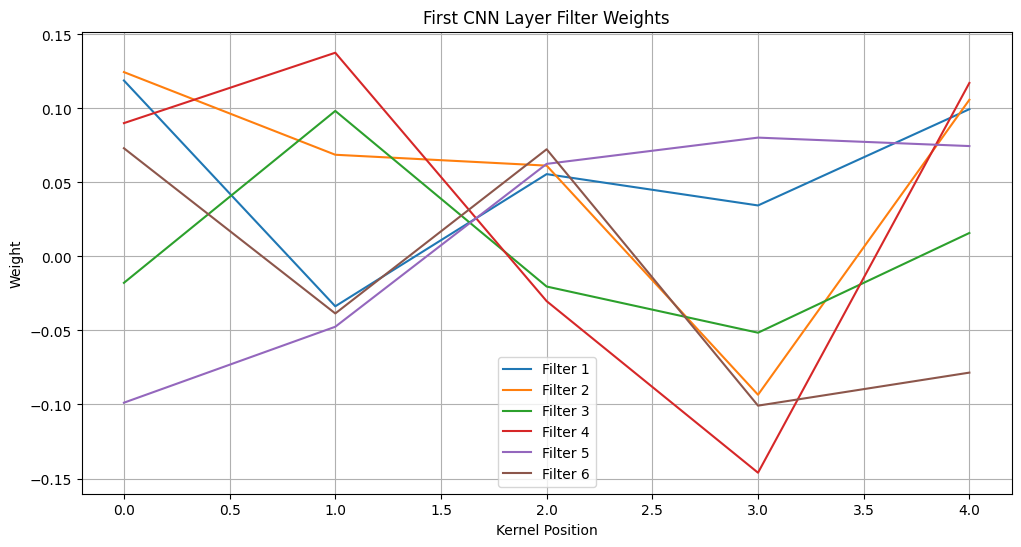

In [24]:
filters, biases = model.layers[1].get_weights()

print("Filter shape:", filters.shape)

plt.figure(figsize=(12, 6))
for i in range(min(6, filters.shape[2])):
    plt.plot(filters[:, 0, i], label=f"Filter {i+1}")

plt.title("First CNN Layer Filter Weights")
plt.xlabel("Kernel Position")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
model.save("final_cnn_bilstm_splice_model.keras")
results_df.to_csv("model_comparison_results.csv", index=False)
report_df.to_csv("classification_report_table.csv")

with open("final_model_metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"F1 Score: {f1}\n")
    f.write(f"AUC Scores: {roc_auc}\n")
    f.write(f"Average Precision Scores: {avg_precision}\n")

print("Model and results saved successfully.")

Model and results saved successfully.
